# Edge Computing Network Simulation
## Mo phong va Danh gia Hieu suat Mang Edge Computing

**Topology:** 1 Cloud Server + 5 Edge Nodes + 100 User Devices
**Algorithms:** Round Robin | Random | Least Loaded | Weighted Load Balancing
**Metrics:** Latency | Throughput | CPU Utilization | Packet Loss


In [1]:
import numpy as np
import random
import csv
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List

%matplotlib inline
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 120})

print("Libraries loaded successfully.")
print(f"  NumPy    : {np.__version__}")
print(f"  Pandas   : {pd.__version__}")
print(f"  Matplotlib: {matplotlib.__version__}")

Libraries loaded successfully.
  NumPy    : 2.4.6
  Pandas   : 3.0.3
  Matplotlib: 3.10.9


## 1. Simulation Parameters

In [2]:
# ── Simulation Parameters ──────────────────────────────────────────────────
SIMULATION_TIME = 1000      # seconds
TIME_STEP       = 1.0       # seconds per step
BANDWIDTH_MBPS  = 100
BASE_DELAY_MS   = 5
QUEUE_CAPACITY  = 30        # max tasks queued per node
RANDOM_SEED     = 42
NUM_STEPS       = int(SIMULATION_TIME / TIME_STEP)

print("Simulation Parameters:")
print(f"  Simulation time : {SIMULATION_TIME} seconds")
print(f"  Time step       : {TIME_STEP} second")
print(f"  Bandwidth       : {BANDWIDTH_MBPS} Mbps")
print(f"  Propagation delay: {BASE_DELAY_MS} ms")
print(f"  Queue capacity  : {QUEUE_CAPACITY} tasks/node")
print(f"  Total steps     : {NUM_STEPS}")


Simulation Parameters:
  Simulation time : 1000 seconds
  Time step       : 1.0 second
  Bandwidth       : 100 Mbps
  Propagation delay: 5 ms
  Queue capacity  : 30 tasks/node
  Total steps     : 1000


## 2. Data Models — Edge Node & Task

In [3]:
@dataclass
class EdgeNode:
    node_id:      int
    cpu_capacity: float    # MIPS
    weight:       float

    queue:         List[float] = field(default_factory=list)
    cpu_used_hist: List[float] = field(default_factory=list)
    latencies:     List[float] = field(default_factory=list)
    dropped:       int = 0
    completed:     int = 0
    total_data_mb: float = 0.0

    @property
    def queue_size(self) -> int:
        return len(self.queue)

    @property
    def current_load_mips(self) -> float:
        return sum(self.queue)

    @property
    def cpu_utilization(self) -> float:
        return np.mean(self.cpu_used_hist) if self.cpu_used_hist else 0.0

    def step_process(self, time_step: float):
        budget = self.cpu_capacity * time_step
        used = 0.0
        while self.queue and budget > 0:
            if self.queue[0] <= budget:
                budget -= self.queue[0]
                used += self.queue[0]
                self.queue.pop(0)
                self.completed += 1
            else:
                self.queue[0] -= budget
                used += budget
                budget = 0
        self.cpu_used_hist.append(min(used / (self.cpu_capacity * time_step), 1.0))


@dataclass
class Task:
    task_id:      int
    cpu_required: float
    data_size_kb: float
    arrive_step:  int


@dataclass
class SimResult:
    algorithm:           str
    scenario:            int
    num_users:           int
    avg_latency_ms:      float
    throughput_mbps:     float
    avg_cpu_utilization: float
    packet_loss_rate:    float
    tasks_total:         int
    tasks_completed:     int


print("Data models defined: EdgeNode, Task, SimResult")


Data models defined: EdgeNode, Task, SimResult


## 3. Edge Node Configuration

In [4]:
def create_edge_nodes() -> List[EdgeNode]:
    configs = [
        (0, 2000, 1.0),
        (1, 3000, 1.5),
        (2, 2500, 1.2),
        (3, 1500, 0.8),
        (4, 3500, 1.8),
    ]
    return [EdgeNode(node_id=i, cpu_capacity=cap, weight=w) for i, cap, w in configs]

def reset_nodes(nodes):
    for n in nodes:
        n.queue.clear()
        n.cpu_used_hist.clear()
        n.latencies.clear()
        n.dropped = 0
        n.completed = 0
        n.total_data_mb = 0.0

nodes = create_edge_nodes()
print(f"{'Node':<6} {'CPU Capacity':>14} {'Weight':>8}")
print("-" * 32)
for n in nodes:
    print(f"  {n.node_id:<4} {n.cpu_capacity:>12} MIPS {n.weight:>7}")


Node     CPU Capacity   Weight
--------------------------------
  0            2000 MIPS     1.0
  1            3000 MIPS     1.5
  2            2500 MIPS     1.2
  3            1500 MIPS     0.8
  4            3500 MIPS     1.8


## 4. Load Balancing Algorithms

In [5]:
class RoundRobinAlgorithm:
    def __init__(self): self._idx = 0
    def reset(self): self._idx = 0
    def select(self, nodes, task):
        node = nodes[self._idx % len(nodes)]
        self._idx += 1
        return node

class RandomAlgorithm:
    def select(self, nodes, task):
        return random.choice(nodes)

class LeastLoadedAlgorithm:
    def select(self, nodes, task):
        return min(nodes, key=lambda n: n.current_load_mips / n.cpu_capacity)

class WeightedLBAlgorithm:
    def select(self, nodes, task):
        scores = [n.weight / (n.current_load_mips / n.cpu_capacity + 0.05) for n in nodes]
        total = sum(scores)
        return random.choices(nodes, weights=[s/total for s in scores], k=1)[0]

print("4 algorithms ready:")
print("  [1] Round Robin           - distributes tasks sequentially")
print("  [2] Random                - distributes tasks randomly")
print("  [3] Least Loaded          - selects node with lowest load")
print("  [4] Weighted LB           - favors nodes with higher capacity")


4 algorithms ready:
  [1] Round Robin           - distributes tasks sequentially
  [2] Random                - distributes tasks randomly
  [3] Least Loaded          - selects node with lowest load
  [4] Weighted LB           - favors nodes with higher capacity


## 5. Task Generator & Latency Model

In [6]:
def generate_tasks_by_step(num_users):
    np.random.seed(RANDOM_SEED)
    tasks_per_step = [[] for _ in range(NUM_STEPS)]
    task_id = 0
    lam = num_users * 0.5 * TIME_STEP
    for step in range(NUM_STEPS):
        for _ in range(np.random.poisson(lam)):
            tasks_per_step[step].append(Task(
                task_id=task_id,
                cpu_required=np.random.uniform(100, 1200),
                data_size_kb=np.random.uniform(10, 500),
                arrive_step=step,
            ))
            task_id += 1
    return tasks_per_step

def compute_latency_ms(node, task):
    tx_ms   = (task.data_size_kb * 8) / BANDWIDTH_MBPS
    prop_ms = BASE_DELAY_MS
    queue_ms = node.queue_size * (task.cpu_required / node.cpu_capacity) * 1000
    proc_ms  = (task.cpu_required / node.cpu_capacity) * 1000
    return tx_ms + prop_ms + queue_ms + proc_ms

print("Task generator and latency model ready.")
print(f"  Latency = Transmission + Propagation ({BASE_DELAY_MS}ms) + Queuing + Processing")


Task generator and latency model ready.
  Latency = Transmission + Propagation (5ms) + Queuing + Processing


## 6. Simulation Engine

In [7]:
def run_simulation(algo_name, algo, nodes, tasks_per_step, scenario, num_users):
    reset_nodes(nodes)
    total_tasks   = sum(len(s) for s in tasks_per_step)
    total_latency = 0.0
    total_data_mb = 0.0
    dropped       = 0

    for step in range(NUM_STEPS):
        for task in tasks_per_step[step]:
            node = algo.select(nodes, task)
            if node.queue_size >= QUEUE_CAPACITY:
                dropped += 1
                node.dropped += 1
                continue
            latency = compute_latency_ms(node, task)
            node.queue.append(task.cpu_required)
            node.latencies.append(latency)
            node.total_data_mb += task.data_size_kb / 1024
            total_latency += latency
            total_data_mb += task.data_size_kb / 1024
        for node in nodes:
            node.step_process(TIME_STEP)

    completed = total_tasks - dropped
    return SimResult(
        algorithm=algo_name, scenario=scenario, num_users=num_users,
        avg_latency_ms=round(total_latency / completed if completed else 0, 2),
        throughput_mbps=round(total_data_mb / SIMULATION_TIME * 8, 4),
        avg_cpu_utilization=round(np.mean([n.cpu_utilization for n in nodes]), 4),
        packet_loss_rate=round(dropped / total_tasks if total_tasks else 0, 4),
        tasks_total=total_tasks,
        tasks_completed=completed,
    )

print("Simulation engine ready.")


Simulation engine ready.


## 7. Run Simulation — All Scenarios

In [8]:
SCENARIOS  = {1: 10, 2: 30, 3: 60, 4: 100}
ALGO_NAMES = ["Round Robin", "Random", "Least Loaded", "Weighted LB"]

rr = RoundRobinAlgorithm()
algorithms = {
    "Round Robin":  rr,
    "Random":       RandomAlgorithm(),
    "Least Loaded": LeastLoadedAlgorithm(),
    "Weighted LB":  WeightedLBAlgorithm(),
}

nodes = create_edge_nodes()
all_results = []

print(f"{'='*72}")
print(f"  Edge Computing Simulation | 5 Nodes | {SIMULATION_TIME}s")
print(f"  Node MIPS: {[n.cpu_capacity for n in nodes]}")
print(f"{'='*72}")

for sc_id, num_users in SCENARIOS.items():
    np.random.seed(RANDOM_SEED + sc_id)
    random.seed(RANDOM_SEED + sc_id)
    tasks_by_step = generate_tasks_by_step(num_users)
    total = sum(len(s) for s in tasks_by_step)
    print(f"\nScenario {sc_id}: {num_users} users | {total} tasks")
    print(f"  {'Algorithm':<18} {'Latency':>10} {'Throughput':>12} {'CPU':>8} {'Loss':>8}")
    print(f"  {'-'*60}")

    for algo_name, algo in algorithms.items():
        if isinstance(algo, RoundRobinAlgorithm):
            algo.reset()
        np.random.seed(RANDOM_SEED)
        random.seed(RANDOM_SEED)
        r = run_simulation(algo_name, algo, nodes, tasks_by_step, sc_id, num_users)
        all_results.append(r)
        print(
            f"  {algo_name:<18} "
            f"{r.avg_latency_ms:>8.1f} ms "
            f"{r.throughput_mbps:>10.3f} Mbps "
            f"{r.avg_cpu_utilization*100:>6.1f}% "
            f"{r.packet_loss_rate*100:>6.1f}%"
        )

print(f"\n{'='*72}")
print(f"  Simulation complete. {len(all_results)} results collected.")
print(f"{'='*72}")


  Edge Computing Simulation | 5 Nodes | 1000s
  Node MIPS: [2000, 3000, 2500, 1500, 3500]

Scenario 1: 10 users | 5045 tasks
  Algorithm             Latency   Throughput      CPU     Loss
  ------------------------------------------------------------
  Round Robin           362.3 ms      9.935 Mbps   28.4%    0.0%
  Random                476.3 ms      9.935 Mbps   28.4%    0.0%
  Least Loaded          353.0 ms      9.935 Mbps   28.0%    0.0%
  Weighted LB           361.6 ms      9.935 Mbps   26.9%    0.0%

Scenario 2: 30 users | 14944 tasks
  Algorithm             Latency   Throughput      CPU     Loss
  ------------------------------------------------------------
  Round Robin          2778.6 ms     28.403 Mbps   78.9%    4.3%
  Random               3227.1 ms     28.165 Mbps   78.3%    5.1%
  Least Loaded          678.0 ms     29.690 Mbps   78.7%    0.0%
  Weighted LB           748.4 ms     29.690 Mbps   78.0%    0.0%

Scenario 3: 60 users | 30336 tasks
  Algorithm             Latency

## 8. Results — Charts

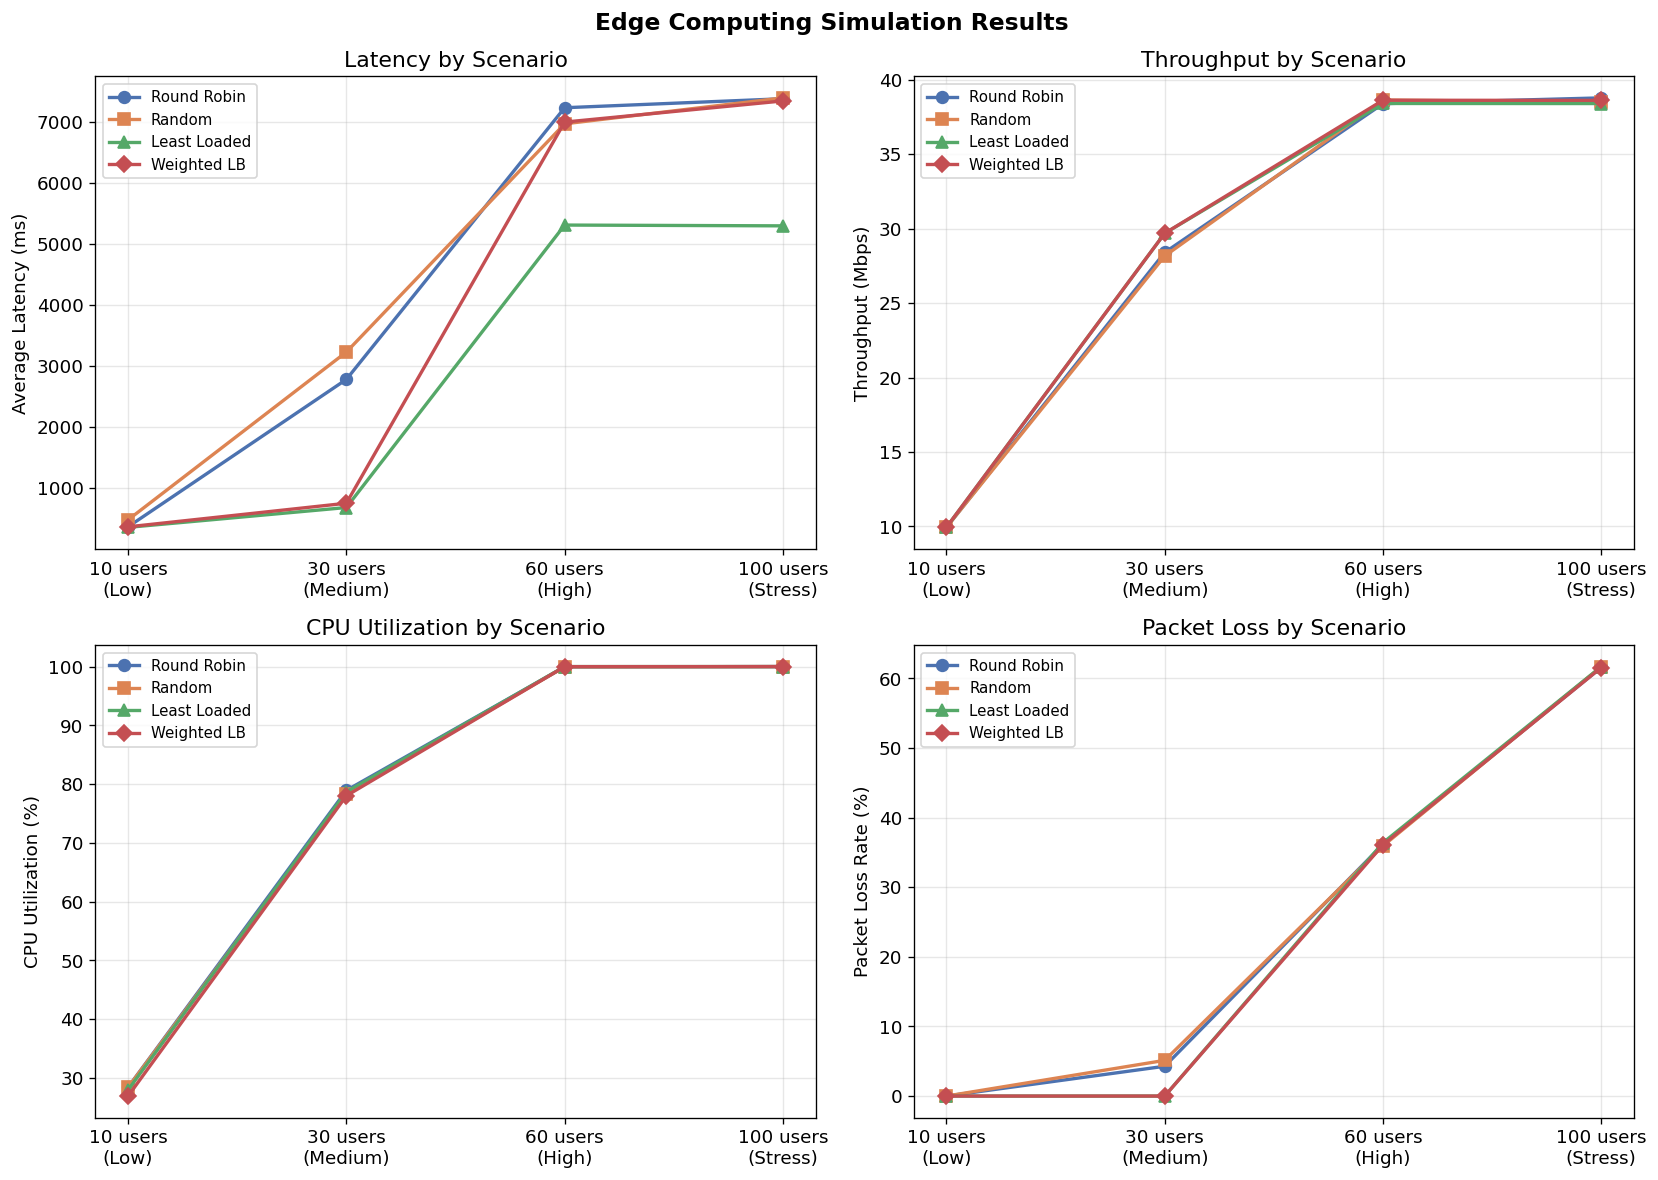

Chart saved to charts/simulation_results.png


In [9]:
COLORS  = {"Round Robin": "#4C72B0", "Random": "#DD8452",
            "Least Loaded": "#55A868", "Weighted LB": "#C44E52"}
MARKERS = {"Round Robin": "o", "Random": "s", "Least Loaded": "^", "Weighted LB": "D"}
SC_LABELS = ["10 users\n(Low)", "30 users\n(Medium)", "60 users\n(High)", "100 users\n(Stress)"]

def get_values(metric):
    out = {}
    for name in ALGO_NAMES:
        out[name] = [
            getattr(next(r for r in all_results if r.algorithm == name and r.scenario == sc), metric)
            * (100 if "utilization" in metric or "loss" in metric else 1)
            for sc in [1, 2, 3, 4]
        ]
    return out

x = np.arange(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Edge Computing Simulation Results", fontsize=14, fontweight="bold")

metrics = [
    ("avg_latency_ms",      "Average Latency (ms)",      "Latency by Scenario"),
    ("throughput_mbps",     "Throughput (Mbps)",          "Throughput by Scenario"),
    ("avg_cpu_utilization", "CPU Utilization (%)",        "CPU Utilization by Scenario"),
    ("packet_loss_rate",    "Packet Loss Rate (%)",       "Packet Loss by Scenario"),
]

for ax, (metric, ylabel, title) in zip(axes.flatten(), metrics):
    vals = get_values(metric)
    for name in ALGO_NAMES:
        ax.plot(x, vals[name], marker=MARKERS[name], color=COLORS[name],
                linewidth=2, markersize=7, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(SC_LABELS)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("charts/simulation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to charts/simulation_results.png")


## 9. Summary — Scenario 2 (Medium Load, 30 users)

In [10]:
print(f"{'Algorithm':<20} {'Latency (ms)':>14} {'Throughput (Mbps)':>18} {'CPU (%)':>9} {'Loss (%)':>10}")
print("-" * 75)
for name in ALGO_NAMES:
    r = next(r for r in all_results if r.algorithm == name and r.scenario == 2)
    print(
        f"{r.algorithm:<20} "
        f"{r.avg_latency_ms:>14.1f} "
        f"{r.throughput_mbps:>18.3f} "
        f"{r.avg_cpu_utilization*100:>9.1f} "
        f"{r.packet_loss_rate*100:>10.1f}"
    )
print()
print("=> Least Loaded and Weighted LB outperform Round Robin and Random")
print("   especially under medium load (Scenario 2).")


Algorithm              Latency (ms)  Throughput (Mbps)   CPU (%)   Loss (%)
---------------------------------------------------------------------------
Round Robin                  2778.6             28.403      78.9        4.3
Random                       3227.1             28.165      78.3        5.1
Least Loaded                  678.0             29.690      78.7        0.0
Weighted LB                   748.4             29.690      78.0        0.0

=> Least Loaded and Weighted LB outperform Round Robin and Random
   especially under medium load (Scenario 2).


## 10. Full Results Table — All Scenarios & Algorithms

In [11]:
df = pd.DataFrame([{
    "Scenario":      r.scenario,
    "Users":         r.num_users,
    "Algorithm":     r.algorithm,
    "Latency (ms)":  r.avg_latency_ms,
    "Throughput (Mbps)": r.throughput_mbps,
    "CPU (%)":       round(r.avg_cpu_utilization * 100, 1),
    "Loss (%)":      round(r.packet_loss_rate * 100, 1),
    "Tasks Total":   r.tasks_total,
    "Completed":     r.tasks_completed,
} for r in all_results])

df.set_index(["Scenario", "Users", "Algorithm"], inplace=True)

def color_loss(val):
    if val == 0.0:   return "background-color: #d4edda; color: #155724"
    if val < 5.0:    return "background-color: #fff3cd; color: #856404"
    return "background-color: #f8d7da; color: #721c24"

def color_latency(val):
    if val < 500:    return "background-color: #d4edda; color: #155724"
    if val < 3000:   return "background-color: #fff3cd; color: #856404"
    return "background-color: #f8d7da; color: #721c24"

df.style \
  .map(color_latency, subset=["Latency (ms)"]) \
  .map(color_loss, subset=["Loss (%)"]) \
  .format({"Latency (ms)": "{:.1f}", "Throughput (Mbps)": "{:.3f}"}) \
  .set_caption("Bảng 3.1 — Kết quả đầy đủ: 4 thuật toán × 4 kịch bản")

## 11. Pivot — So sánh Latency theo kịch bản

In [12]:
df_reset = df.reset_index()

# Latency pivot
pivot_latency = df_reset.pivot_table(
    index="Algorithm", columns="Users",
    values="Latency (ms)", aggfunc="first"
)
pivot_latency.columns = [f"{u} users" for u in pivot_latency.columns]

print("=== Bảng 3.2 — Độ trễ trung bình (ms) theo kịch bản ===")
display(pivot_latency.style
    .background_gradient(cmap="RdYlGn_r", axis=None)
    .format("{:.1f}")
    .set_caption("Độ trễ (ms) — thấp = tốt"))

# Loss pivot
pivot_loss = df_reset.pivot_table(
    index="Algorithm", columns="Users",
    values="Loss (%)", aggfunc="first"
)
pivot_loss.columns = [f"{u} users" for u in pivot_loss.columns]

print("\n=== Bảng 3.3 — Tỷ lệ mất gói (%) theo kịch bản ===")
display(pivot_loss.style
    .background_gradient(cmap="RdYlGn_r", axis=None)
    .format("{:.1f}%")
    .set_caption("Packet Loss (%) — thấp = tốt"))

=== Bảng 3.2 — Độ trễ trung bình (ms) theo kịch bản ===


,10 users,30 users,60 users,100 users
Algorithm,,,,
Least Loaded,353.0,678.0,5308.8,5295.9
Random,476.3,3227.1,6968.5,7393.9
Round Robin,362.3,2778.6,7232.4,7379.9
Weighted LB,361.6,748.4,6997.1,7343.9



=== Bảng 3.3 — Tỷ lệ mất gói (%) theo kịch bản ===


,10 users,30 users,60 users,100 users
Algorithm,,,,
Least Loaded,0.0%,0.0%,36.4%,61.7%
Random,0.0%,5.1%,35.9%,61.7%
Round Robin,0.0%,4.3%,36.2%,61.6%
Weighted LB,0.0%,0.0%,36.1%,61.6%
